# ⛔ Modelo A — contraexemplo (NÃO é o modelo da entrega)

> **Este modelo é inválido por data leakage.** Ele usa features do **mesmo ano**
> do resultado que tenta prever. Os ~99% de acurácia são artificiais — o modelo
> está "vendo a resposta". Está aqui só para **demonstrar o problema**; o modelo
> real da Fase 3 é o `03b_modelo_defasagem_temporal.ipynb`.
>
> Diagnóstico completo do vazamento: `03a_diagnostico_vazamento_dados.ipynb`.

Mesmo target do modelo real (`em_risco` = taxa abaixo da média nacional do ano),
mesma validação — só as features mudam.


In [1]:
import sys; sys.path.append("..")
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")

from src import config
from src.preprocessing.gold_consumer import load_gold
from src.preprocessing.features import ref_nacional_por_ano

df = load_gold(config.GOLD_DATASET)
ref = ref_nacional_por_ano(load_gold(config.GOLD_REF_NACIONAL))

df = df.copy()
df["cod_uf"] = df.id_municipio.astype(str).str.zfill(7).str[:2].astype(int)
df["ref_nacional"] = df.ano.map(ref)
df = df.dropna(subset=["ref_nacional"])
df["em_risco"] = (df.taxa_alfabetizacao < df.ref_nacional).astype(int)
df["nivel_num"] = pd.to_numeric(df.nivel_alfabetizacao, errors="coerce")
print(df.shape, "| prevalência em_risco:", round(df.em_risco.mean(), 3))


2026-09-05 12:46:39 [INFO] Usando cache local: data\gold\indicador_municipio.parquet


2026-09-05 12:46:39 [INFO] Usando cache local: data\gold\painel_nacional.parquet


(11030, 22) | prevalência em_risco: 0.384


## Features do MESMO ANO (é aqui que vaza)

`media_portugues`, `taxa_meta_base`, `nivel_alfabetizacao` são medidas da mesma
prova que gera o alvo. `meta_*` embutem a taxa-base do município.


In [2]:
LEAK_FEATURES = ["media_portugues", "taxa_meta_base", "nivel_num", "percentual_participacao",
                 "meta_2024", "meta_2025", "meta_2026", "meta_2027"]

from sklearn.model_selection import StratifiedShuffleSplit
X, y, g = df[LEAK_FEATURES], df["em_risco"], df["cod_uf"]
tr, te = next(StratifiedShuffleSplit(1, test_size=0.2, random_state=42).split(X, y))
X_train, X_test, y_train, y_test = X.iloc[tr], X.iloc[te], y.iloc[tr], y.iloc[te]


In [3]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

modelo_A = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=10,
                                     class_weight="balanced", random_state=42, n_jobs=-1)),
]).fit(X_train, y_train)

y_pred = modelo_A.predict(X_test)
y_proba = modelo_A.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred, target_names=["fora de risco", "EM RISCO"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}   PR-AUC: {average_precision_score(y_test, y_proba):.3f}")
print("\n^ Perto do perfeito. Bom demais pra ser verdade — e não é.")


               precision    recall  f1-score   support

fora de risco       0.99      0.98      0.98      1358
     EM RISCO       0.96      0.98      0.97       848

     accuracy                           0.98      2206
    macro avg       0.97      0.98      0.98      2206
 weighted avg       0.98      0.98      0.98      2206

ROC-AUC: 0.997   PR-AUC: 0.995

^ Perto do perfeito. Bom demais pra ser verdade — e não é.


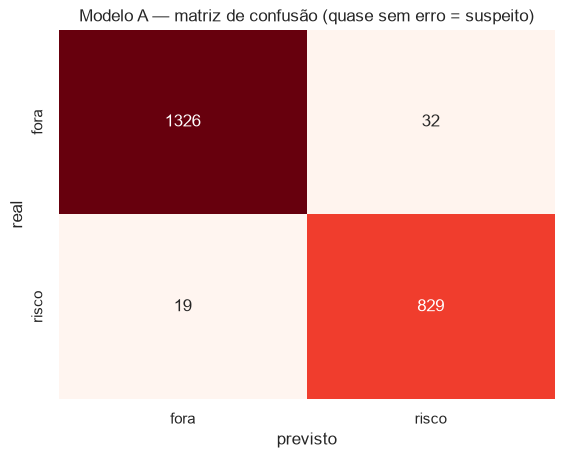

In [4]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", cbar=False,
            xticklabels=["fora", "risco"], yticklabels=["fora", "risco"])
plt.title("Modelo A — matriz de confusão (quase sem erro = suspeito)")
plt.xlabel("previsto"); plt.ylabel("real"); plt.show()


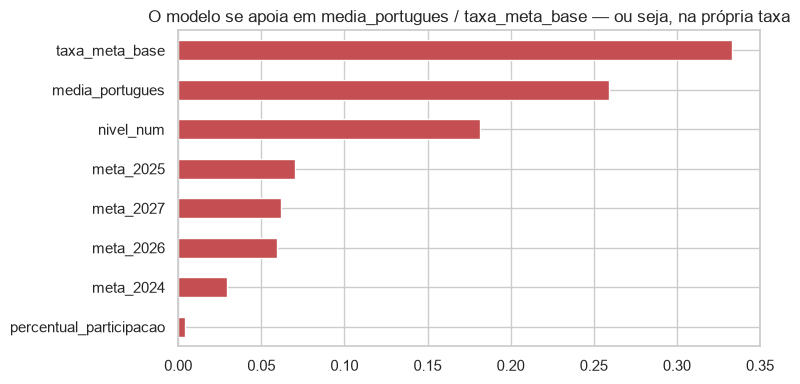

percentual_participacao    0.004
meta_2024                  0.030
meta_2026                  0.060
meta_2027                  0.062
meta_2025                  0.071
nivel_num                  0.182
media_portugues            0.259
taxa_meta_base             0.333
dtype: float64

In [5]:
imp = pd.Series(modelo_A.named_steps["model"].feature_importances_, index=LEAK_FEATURES).sort_values()
imp.plot.barh(color="#c44e52", figsize=(8, 4))
plt.title("O modelo se apoia em media_portugues / taxa_meta_base — ou seja, na própria taxa")
plt.tight_layout(); plt.show()
imp.round(3)


## Por que isto é inválido

`media_portugues` e `taxa_meta_base` do ano X têm correlação ~0,93–0,98 com a
`taxa_alfabetizacao` do ano X (ver `03a`). O modelo não "aprendeu" a prever
risco — ele está lendo uma cópia do resultado.

Na prática seria inútil: para usar o Modelo A, o gestor já precisaria ter em
mãos o resultado da prova de 2024 — momento em que a previsão não serve mais
para nada.

| | Modelo A (mesmo ano) | Modelo D (defasado) — **entrega** |
|---|---|---|
| ROC-AUC | ~0,99 (**inválido**) | ~0,82 (honesto) |
| Informação usada | resultado do próprio ano | só o ano anterior |
| Serve para agir a tempo? | ❌ | ✅ |

**Regra:** nenhuma feature do mesmo ano do alvo entra no modelo.
